In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('..')
from helpers import (
    get_bulk_power_sales,
    get_service_territories,
    get_county2zone
)

In [2]:
def read_sales_to_ultimate_customers(load_year):    
    if load_year == 2019:
        column_rename_map = {
            "Unnamed: 1": "Utility Number",
            "Unnamed: 2": "Utility Name",
            "Unnamed: 3": "Part",
            "Unnamed: 4": "Service Type",
            "Unnamed: 6": "State",
            "Unnamed: 7": "Ownership",
            "Unnamed: 8": "BA Code",
            "Unnamed: 11": "residential_sales_mwh",
            "Unnamed: 14": "commercial_sales_mwh",
            "Unnamed: 17": "industrial_sales_mwh",
            "Unnamed: 20": "transportation_sales_mwh",
        }
    else:
        column_rename_map = {
            "Unnamed: 1": "Utility Number",
            "Unnamed: 2": "Utility Name",
            "Unnamed: 3": "Part",
            "Unnamed: 4": "Service Type",
            "Unnamed: 6": "State",
            "Unnamed: 7": "Ownership",
            "Unnamed: 8": "BA Code",
            "Unnamed: 10": "residential_sales_mwh",
            "Unnamed: 13": "commercial_sales_mwh",
            "Unnamed: 16": "industrial_sales_mwh",
            "Unnamed: 19": "transportation_sales_mwh",
        }

    df = pd.read_excel(f"../data/sales/Sales_Ult_Cust_{load_year}.xlsx")
    df = df[column_rename_map.keys()]
    df.columns = df.columns.map(column_rename_map)
    df = (
        df.loc[2:]
        .dropna(subset='Utility Number')
        .reset_index(drop=True)
    )

    return df

def get_statewide_sales(load_year):
    sales_ult_cust = read_sales_to_ultimate_customers(load_year)

    for col in [
        'residential_sales_mwh',
        'commercial_sales_mwh',
        'industrial_sales_mwh',
        'transportation_sales_mwh',
    ]:
        sales_ult_cust[col] = (
            pd.to_numeric(sales_ult_cust[col], errors='coerce')
            .astype(float)
            .fillna(0)
        )

    ### Front-of-the-meter sales
    ftm_sales = (
        sales_ult_cust.loc[(
            (~sales_ult_cust['State'].isin(['HI', 'AK']))
            & (sales_ult_cust['Ownership'] != "Behind the Meter")
            & (sales_ult_cust['Service Type'] != 'Energy')
        )]
        .dropna(how='all')
    )
    ftm_residential_sales_by_state = (
        ftm_sales.groupby('State')
        ['residential_sales_mwh']
        .sum()
        .rename('ftm_residential_sales_mwh')
    )
    ftm_commercial_sales_by_state = (
        ftm_sales.groupby('State')
        ['commercial_sales_mwh']
        .sum()
        .rename('ftm_commercial_sales_mwh')
    )
    ftm_industrial_sales_by_state = (
        ftm_sales.groupby('State')
        ['industrial_sales_mwh']
        .sum()
        .rename('ftm_industrial_sales_mwh')
    )
    ftm_transportation_sales_by_state = (
        ftm_sales.groupby('State')
        ['transportation_sales_mwh']
        .sum()
        .rename('ftm_transportation_sales_mwh')
    )
    
    ### Behind-the-meter sales
    btm_sales = (
        sales_ult_cust.loc[(
            (~sales_ult_cust['State'].isin(['HI', 'AK']))
            & (sales_ult_cust['Ownership'] == "Behind the Meter")
        )]
        .dropna(how='all')
    )
    btm_residential_sales_by_state = (
        btm_sales.groupby('State')
        ['residential_sales_mwh']
        .sum()
        .rename('btm_residential_sales_mwh')
    )
    btm_non_residential_sales_by_state = (
        btm_sales.groupby('State')
        [['commercial_sales_mwh', 'industrial_sales_mwh', 'transportation_sales_mwh']]
        .sum()
        .sum(axis=1)
        .rename('btm_non_residential_sales_mwh')
    )
    
    statewide_sales = (
        pd.concat([
            ftm_residential_sales_by_state,
            ftm_commercial_sales_by_state,
            ftm_industrial_sales_by_state,
            ftm_transportation_sales_by_state,
        ], axis=1)
        .fillna(0)
    )

    return statewide_sales

In [ ]:
def assign_sales_to_counties(accounted_sales, service_territories, county2zone, load_year):
    county_sales = (
        service_territories.merge(
            county2zone[['county_state', 'FIPS', 'population']],
            on='county_state',
            how='left'
        )
        .merge(accounted_sales, on=['Utility Number', 'State'], how='right')
    )

    # Add CT legacy county populations
    ct_town_populations = (
        pd.read_csv(
            '../data/population/connecticut/ct_town_populations_by_year.csv',
            usecols=['Town', 'County', 'planning_region_FIPS', str(load_year)]
        )
        .rename(columns={str(load_year): 'town_population'})
    )
    ct_county_populations = ct_town_populations.groupby('County')['town_population'].sum()
    county_sales.loc[county_sales.State == 'CT', 'population'] = (
        county_sales.County.map(ct_county_populations)
    )

    # Assign a portion of each utility's sales to its served counties according to population
    county_sales['population'] = county_sales['population'].fillna(1)
    county_sales['pct_of_pop'] = (
        county_sales.groupby(["Utility Number", "State"], dropna=False)
        ['population'].transform(lambda x: (x / x.sum()))
    )
    county_sales['Megawatthours'] = county_sales['Megawatthours'] * county_sales['pct_of_pop']

    # Connecticut sales use the legacy counties, so use the town-county-planning region
    # crosswalk and town populations to disaggregate sales to the town level and then
    # reaggregate to the planning region level
    ct_county_sales = (
        county_sales.loc[county_sales.State == 'CT']
        .copy()
        .reset_index(drop=True)
    )
    ct_town_populations['pct_of_county_pop'] = (
        ct_town_populations.groupby("County")
        ['town_population'].transform(lambda x: (x / x.sum()))
    )
    ct_county_sales = (
        ct_county_sales.merge(
            ct_town_populations[[
                'County',
                'planning_region_FIPS',
                'pct_of_county_pop'
            ]],
            on='County',
            how='left'
        )
        .dropna(axis=1)
        .rename(columns={'planning_region_FIPS': 'FIPS'})
    )
    ct_county_sales['Megawatthours'] = (
        ct_county_sales['Megawatthours'] * ct_county_sales['pct_of_county_pop']
    )
    ct_county_sales = ct_county_sales.drop(
        columns=['County', 'county_lower', 'county_state', 'pct_of_county_pop']
    )
    ct_county_sales = (
        ct_county_sales.groupby(
            list(ct_county_sales.columns.difference(['Megawatthours'])), as_index=False
        )
        ['Megawatthours'].sum()
    )
    county_sales = (
        pd.concat([county_sales.loc[county_sales.State != 'CT'], ct_county_sales])
        .reset_index(drop=True)
    )

    return county_sales

def get_county_sales(
    load_year,
    bulk_power_sales,
    county2zone,
    service_territories,
):
    # Separate sales between accounted and unaccounted, where unaccounted sales
    # are those whose utility-state pair has no known service territory
    # or belong to dropped BAs
    unaccounted_sales = (
        bulk_power_sales.loc[(
            ~bulk_power_sales['state_utility'].isin(service_territories['state_utility'])
        )]
        .groupby(['eia_code', 'State'], dropna=False)
        .Megawatthours.sum()
    )
    # Note we keep sales from dropped BAs as part of accounted sales to maintain
    # county-level information, but they are only processed once in the handling
    # for unaccounted sales
    accounted_sales = (
        (
            bulk_power_sales.loc[(
                bulk_power_sales['state_utility'].isin(service_territories['state_utility'])
            )]
        )
        .groupby(['Utility Number', 'State'], dropna=False)
        .sum(numeric_only=True)
        .reset_index()
    )
    county_sales = assign_sales_to_counties(
        accounted_sales, service_territories, county2zone, load_year
    )

    return county_sales, unaccounted_sales

In [4]:
def get_actual_ca_county_load():
    df_ca = pd.read_excel('data/county_load_magnitudes/california/AGG_CONSUMPTION_ELEC_COUNTY_TBL_ada.xlsx')
    df_ca['county_name'] = df_ca['COUNTY_NAME'].str.lower()
    df_ca = df_ca.merge(ca_county2zone[['FIPS', 'county_name']], on='county_name')
    df_ca = (
        df_ca.groupby(['YEAR', 'FIPS'], as_index=False)
        ['GWH']
        .sum()
        .rename(columns={'YEAR': 'year', 'GWH': 'expected'})
    )
    df_ca['expected'] *= 1e3
    df_ca = df_ca.loc[df_ca.year == 2023].reset_index(drop=True).copy()  

    return df_ca

In [5]:
state = 'CA'

In [6]:
load_year = 2023

county2zone = get_county2zone(load_year)
ca_county2zone = county2zone.loc[county2zone.state == state].copy()
ca_county_fips_map = dict(zip(ca_county2zone['county_name'].str.upper(), ca_county2zone['FIPS']))

In [7]:
df_ca = get_actual_ca_county_load()
statewide_sales = get_statewide_sales(2023)
ca_sales = statewide_sales.loc[state]

In [8]:
df_gdp = pd.read_excel("data/lagdp1224.xlsx")
df_gdp.columns = df_gdp.loc[2]
df_gdp = df_gdp.loc[3:]
df_gdp = df_gdp.iloc[:, :5]
df_gdp.columns = ['County', 2020, 2021, 2022, 2023]

df_gdp_ca = df_gdp.loc[201:258].reset_index(drop=True).copy()
df_gdp_ca['county_name'] = df_gdp_ca['County'].str.lower()
df_gdp_ca = (
    df_gdp_ca.merge(ca_county2zone[['FIPS', 'county_name']], on='county_name')
    .set_index('FIPS')
    .rename(columns={2023: 'total_gdp'})
    [['total_gdp']]
)

df = pd.read_csv(f'data/{state}_industrial_gdp_by_county.csv', skiprows=3)
df = df.rename(columns={'2023': 'industrial_gdp'})
df['industrial_gdp'] = pd.to_numeric(df['industrial_gdp'], errors='coerce')
df = df.dropna(subset='industrial_gdp')
df['FIPS'] = 'p' + df['GeoFips']

state_fips = 'p' + df.iloc[0]['GeoFips']
df = df.groupby('FIPS')['industrial_gdp'].sum().drop(state_fips).reset_index()

df_gdp_ca = (
    df_gdp_ca.merge(df, on='FIPS')
    .assign(non_industrial_gdp=lambda x: x['total_gdp'] - x['industrial_gdp'])
)

for col in ['industrial_gdp', 'non_industrial_gdp', 'total_gdp']:
    df_gdp_ca[col] /= df_gdp_ca[col].sum()

In [9]:
county_sales = (
    pd.read_csv('../data/county_ftm_sales_estimates.csv', usecols=['FIPS', '2023'])
    .rename(columns={'2023': 'value'})
)

#### Population-based sales allocation vs. actual consumption

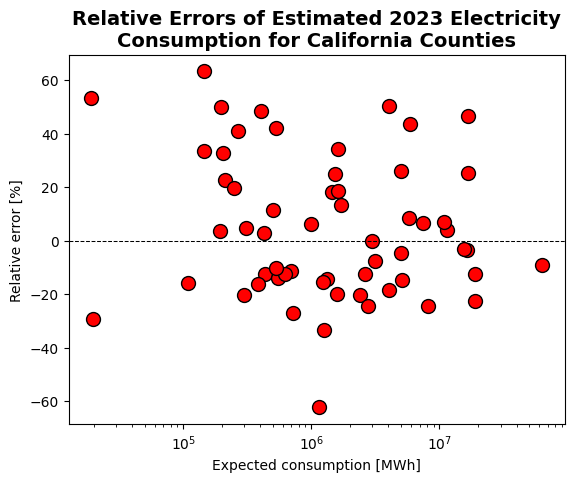

In [11]:
df_ca_method_1 = pd.read_hdf('../data/outputs/historic_load_hourly_2016_2023_county.h5')
df_ca_method_1 = df_ca_method_1.loc[df_ca_method_1.index.year == 2023][ca_county2zone.FIPS]
df_ca['method_1'] = df_ca['FIPS'].map(df_ca_method_1.sum())

ca_county_sales = (
    county_sales.loc[county_sales.FIPS.isin(ca_county2zone.FIPS)]
    .reset_index(drop=True)
    .copy()
)
ca_non_sales_load = (
    df_ca.set_index('FIPS')['method_1']
    .sub(ca_county_sales.set_index('FIPS')['value'])
)

plt.scatter(
    x=df_ca['expected'],
    y=100 * (df_ca["expected"] - df_ca['method_1']) / (df_ca['expected']),
    facecolors='red',
    edgecolors='black',
    s=100
)
plt.xlabel("Expected consumption [MWh]")
plt.ylabel("Relative error [%]")
plt.xscale('log')
plt.title("Relative Errors of Estimated 2023 Electricity\nConsumption for California Counties", fontsize=14, fontweight='bold')
plt.axhline(0, color='black', ls="--", lw=0.75)

plt.savefig(f'california_load_magnitude_comparison_method_1.png', dpi=300, bbox_inches='tight')
# plt.show()

#### All allocation methods vs. actual consumption

In [12]:
# Method 1: Population-based sales allocation (paper)
df_ca_method_1 = pd.read_hdf('../data/outputs/historic_load_hourly_2016_2023_county.h5')
df_ca_method_1 = df_ca_method_1.loc[df_ca_method_1.index.year == 2023][ca_county2zone.FIPS]
df_ca['method_1'] = df_ca['FIPS'].map(df_ca_method_1.sum())

ca_county_sales = (
    county_sales.loc[county_sales.FIPS.isin(ca_county2zone.FIPS)]
    .reset_index(drop=True)
    .copy()
)
ca_non_sales_load = (
    df_ca.set_index('FIPS')['method_1']
    .sub(ca_county_sales.set_index('FIPS')['value'])
)

In [13]:
county_sales = (
    pd.read_csv('../data/county_ftm_sales_estimates.csv', usecols=['FIPS', '2023'])
    .rename(columns={'2023': 'value'})
)
ca_county_sales = (
    county_sales.loc[county_sales.FIPS.isin(ca_county2zone.FIPS)]
    .reset_index(drop=True)
    .copy()
)
ca_non_sales_load = (
    df_ca.set_index('FIPS')['method_1']
    .sub(ca_county_sales.set_index('FIPS')['value'])
)

In [14]:
# Method 2: GDP-based sales allocation
df_ca_method_2 = df_gdp_ca.set_index('FIPS')[['total_gdp']].copy()
df_ca_method_2['value'] = df_ca_method_2['total_gdp'] * ca_sales.sum()
df_ca_method_2 = df_ca_method_2['value'].add(ca_non_sales_load)
df_ca['method_2'] = df_ca['FIPS'].map(df_ca_method_2)

In [15]:
# Method 3: Population and sector-specific GDP-based sales allocation
df_ca_method_3 = df_gdp_ca[['FIPS', 'industrial_gdp', 'non_industrial_gdp']].copy()
df_ca_method_3 = (
    df_ca_method_3.merge(
        ca_county2zone[['FIPS', 'population']],
        on='FIPS'
    )
    .set_index('FIPS')
)
df_ca_method_3['population'] = (
    df_ca_method_3['population'] / df_ca_method_3['population'].sum()
)
df_ca_method_3['residential_load'] = (
    df_ca_method_3['population'] * ca_sales['ftm_residential_sales_mwh']
)
df_ca_method_3['commercial_transportation_load'] = (
    df_ca_method_3['non_industrial_gdp'] * (
        ca_sales['ftm_commercial_sales_mwh'] + ca_sales['ftm_transportation_sales_mwh']
    )
)
df_ca_method_3['industrial_load'] = (
    df_ca_method_3['industrial_gdp'] * ca_sales['ftm_industrial_sales_mwh']
)
df_ca_method_3['value'] = (
    df_ca_method_3['residential_load']
    + df_ca_method_3['commercial_transportation_load']
    + df_ca_method_3['industrial_load']
)
df_ca_method_3 = df_ca_method_3['value'].add(ca_non_sales_load)
df_ca['method_3'] = df_ca['FIPS'].map(df_ca_method_3)

In [16]:
# Method 4: Shapefile-based sales allocation
df_ca_method_4 = (
    pd.read_csv(
        '../data/county_load_magnitudes.csv',
        usecols=['FIPS', '2023'],
        index_col=['FIPS']
    )
    .rename(columns={'2023': 'load'})
)
df_ca_method_4 = df_ca_method_4.loc[ca_county2zone.FIPS]
df_ca_method_4['load'] = (
    df_ca_method_4['load']
    / df_ca_method_4['load'].sum()
    * ca_sales.sum()
)
df_ca_method_4['load'] = df_ca_method_4['load'] + ca_non_sales_load
df_ca['method_4'] = df_ca['FIPS'].map(df_ca_method_4['load'])

In [ ]:
# Method 5: Utility-based sales allocation
with open("../config/old_to_new_utility_map.json") as f:
    utility_id_updates = json.load(f)

bulk_power_sales = get_bulk_power_sales(load_year, utility_id_updates)
service_territories = get_service_territories(county2zone, load_year)
county_sales, _ = get_county_sales(
    load_year,
    bulk_power_sales,
    county2zone,
    service_territories
)
county_sales = (
    county_sales.rename(columns={"Megawatthours": "value"})
    .groupby('FIPS', as_index=False)
    ['value']
    .sum()
)

df_ca_method_5 = (
    county_sales.loc[county_sales.FIPS.isin(ca_county2zone.FIPS)]
    .copy()
    .set_index('FIPS')
)
df_ca_method_5['value'] = (
    df_ca_method_5['value'] / df_ca_method_5['value'].sum() * ca_sales.sum()
)
df_ca_method_5 = df_ca_method_5['value'].add(ca_non_sales_load)
df_ca['method_5'] = df_ca['FIPS'].map(df_ca_method_5)

In [18]:
df_ca = df_ca.drop(columns=['year'])

In [19]:
for i in range(1, 6):
    col = f"method_{i}"
    df_ca[col] = 100 * (df_ca["expected"] - df_ca[col]) / (df_ca['expected'])

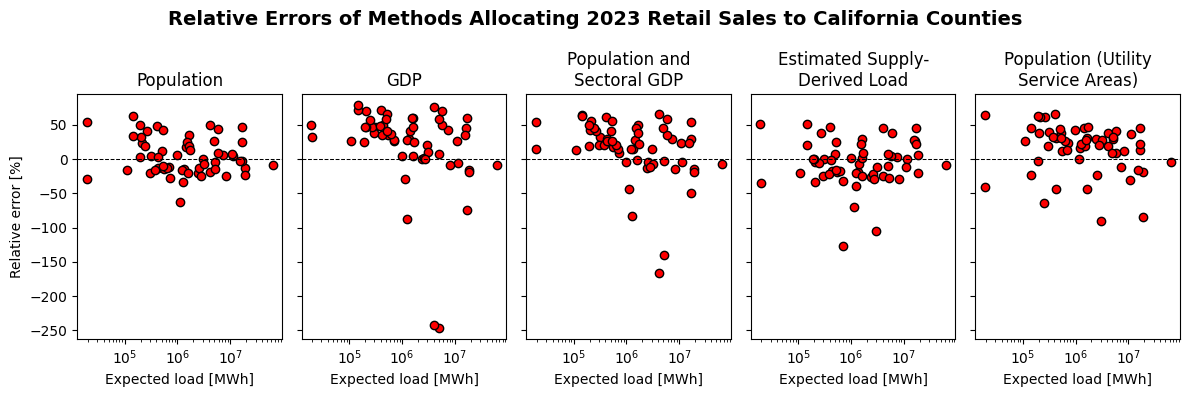

In [20]:
method_num_title_map = {
    1: "Population",
    2: "GDP",
    3: "Population and\nSectoral GDP",
    4: "Estimated Supply-\nDerived Load",
    5: "Population (Utility\nService Areas)"
}

fig, ax = plt.subplots(1, 5, figsize=(12, 4), sharey=True)

for i in range(5):
    method_num = i + 1
    ax[i].scatter(
        x=df_ca['expected'],
        y=df_ca[f"method_{method_num}"],
        facecolors='red',
        edgecolors='black'
    )
    ax[i].set_xlabel("Expected load [MWh]")
    ax[i].set_xscale('log')
    ax[i].set_title(method_num_title_map[method_num])
    ax[i].axhline(0, color='black', ls="--", lw=0.75)
    
ax[0].set_ylabel("Relative error [%]")
fig.suptitle('Relative Errors of Methods Allocating 2023 Retail Sales to California Counties', fontsize=14, fontweight='bold')
plt.tight_layout()

# plt.savefig(f'california_load_magnitude_comparison_all_methods.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
for i in range(1, 6):
    print(f"Method {i} median: {round(df_ca[f'method_{i}'].abs().median(), 1)}")

Method 1 median: 18.4
Method 2 median: 41.0
Method 3 median: 26.7
Method 4 median: 21.2
Method 5 median: 30.0


In [22]:
for i in range(1, 6):
    print(f"Method {i} mean: {round(df_ca[f'method_{i}'].abs().mean(), 1)}")

Method 1 mean: 21.7
Method 2 mean: 46.0
Method 3 mean: 34.7
Method 4 mean: 24.3
Method 5 mean: 32.6


In [23]:
for i in range(1, 6):
    print(f"Method {i} max: {round(df_ca[f'method_{i}'].abs().max(), 1)}")

Method 1 max: 63.3
Method 2 max: 246.5
Method 3 max: 166.6
Method 4 max: 126.7
Method 5 max: 89.9
